In [1]:
import pandas as pd

df = pd.read_csv("ToyotaCorolla - MLR.csv")
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


### Data Overview

Dataset contains car features like age, km driven, fuel type etc.  
We need to predict price using these variables.

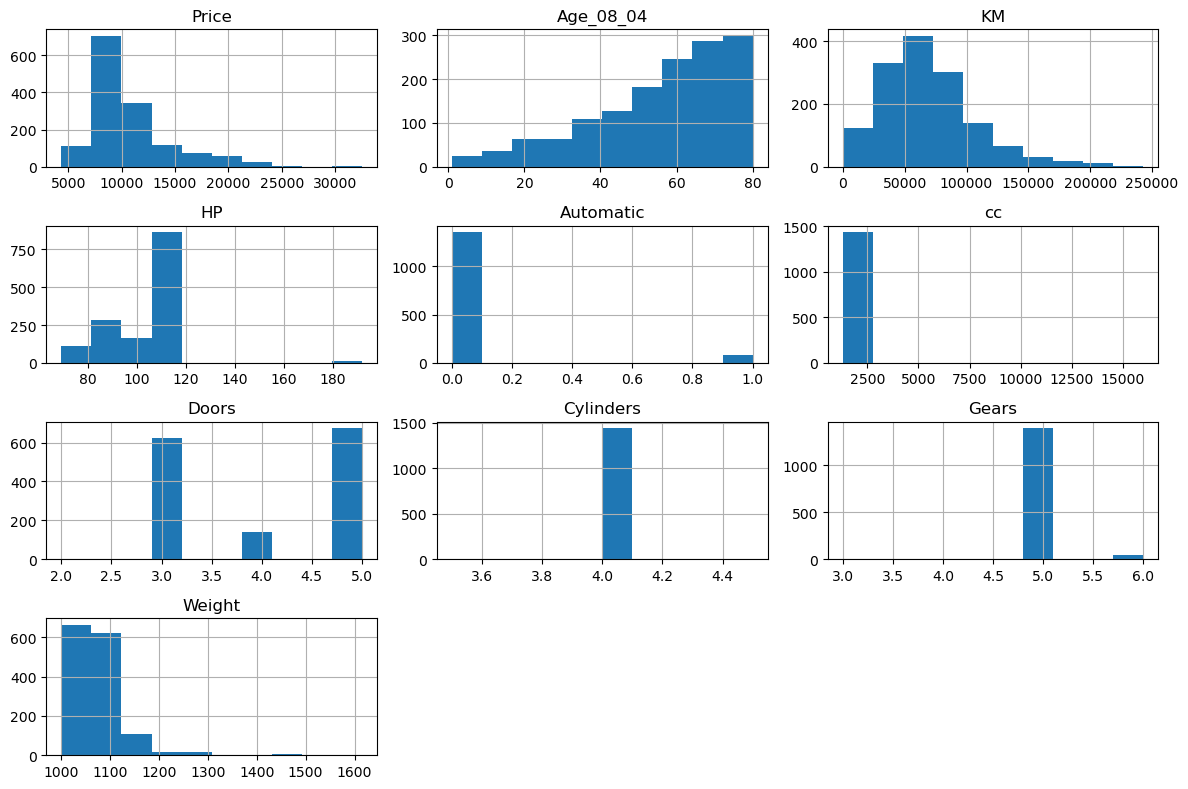

In [6]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

In [19]:
df = pd.get_dummies(df, drop_first=True)

In [23]:
df = df.astype(int)
df.dtypes

Price               int64
Age_08_04           int64
KM                  int64
HP                  int64
Automatic           int64
cc                  int64
Doors               int64
Cylinders           int64
Gears               int64
Weight              int64
Fuel_Type_Diesel    int64
Fuel_Type_Petrol    int64
dtype: object

Price               int64
Age_08_04           int64
KM                  int64
HP                  int64
Automatic           int64
cc                  int64
Doors               int64
Cylinders           int64
Gears               int64
Weight              int64
Fuel_Type_Diesel    int64
Fuel_Type_Petrol    int64
dtype: object

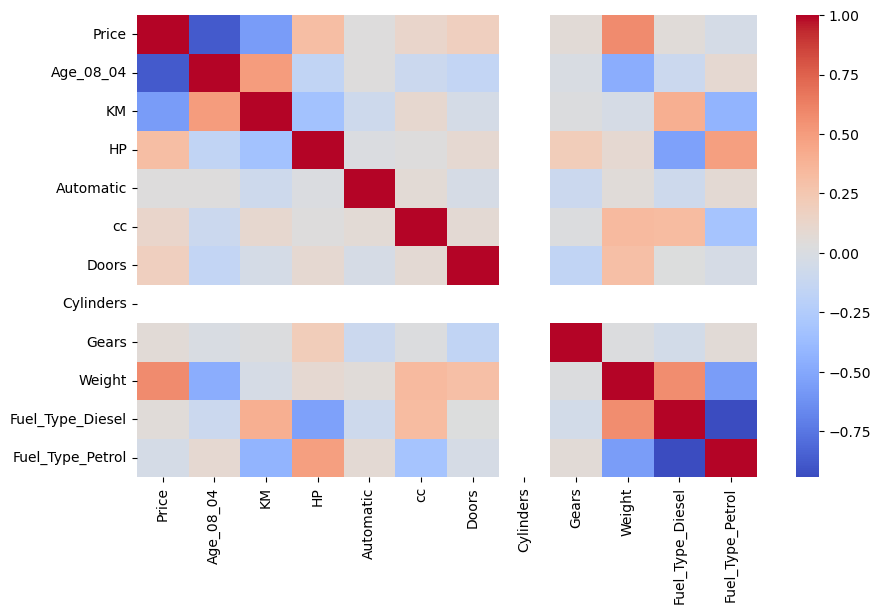

In [16]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Split
X = df.drop("Price", axis=1)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model1 = LinearRegression()
model1.fit(X_train, y_train)

# Predict
y_pred = model1.predict(X_test)

# Evaluate
print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2: 0.8348888040611082
MSE: 2203043.823143702


In [25]:
import numpy as np
np.sqrt(2203043)

np.float64(1484.2651380396967)

### Model Evaluation

The model achieved an R2 score of 0.83, which indicates that it explains most of the variability in car prices.  

The RMSE is around 1500, meaning predictions deviate by approximately this amount from actual values.  

Overall, the model performs well but still has some prediction error, which may be due to missing variables or multicollinearity.

In [26]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

from sklearn.metrics import r2_score, mean_squared_error

print("Ridge R2:", r2_score(y_test, y_pred_ridge))
print("Ridge MSE:", mean_squared_error(y_test, y_pred_ridge))

Ridge R2: 0.8351359377712335
Ridge MSE: 2199746.370233341


In [27]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

print("Lasso R2:", r2_score(y_test, y_pred_lasso))
print("Lasso MSE:", mean_squared_error(y_test, y_pred_lasso))

Lasso R2: 0.8349467801805
Lasso MSE: 2202270.2600246826


### Model Comparison and Conclusion

All three models (Linear, Ridge and Lasso) performed similarly with R2 around 0.83.

Ridge regression showed slightly better performance with lower MSE, indicating minor multicollinearity in the dataset.

Lasso regression did not significantly improve the model, which suggests that most features are relevant and there are no unnecessary variables.

Overall, the linear regression model performs well, and Ridge provides a slightly more stable solution.

### Interview Questions

Normalization scales values between 0 and 1, while standardization converts data to mean 0 and standard deviation 1.  
This helps improve model performance when features have different scales.

Multicollinearity can be handled using:
- Removing correlated variables
- Using Ridge regression
- Using Lasso regression for feature selection